<a href="https://colab.research.google.com/github/Alamgir-JUST/Skill-Morph/blob/main/PCA_with_CICIoT2023_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import matplotlib.pyplot as plt
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [15]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Dataset**

In [16]:
# Path to processed dataset
file_path = "/content/drive/MyDrive/CICIoT2023/ProcessedDF/CICIoT2023_processed.csv"

# Load dataset
df = pd.read_csv(file_path)

In [17]:
df

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,-0.020380,-0.166589,-0.342702,-0.167740,-0.090701,-0.090701,-0.001593,3.249644,-0.510612,3.171723,...,-0.207523,-0.292182,0.008985,0.001476,-0.316405,-0.207354,-0.090544,-0.414082,0.001393,DDoS
1,-0.020380,-0.166582,-0.305765,-0.167740,-0.090661,-0.090661,-0.001593,-0.307726,-0.510612,-0.315286,...,-0.190002,-0.279638,-0.015480,0.001476,-0.308026,-0.189756,-0.090075,-0.199615,0.001393,DoS
2,-0.020380,-0.166705,-0.902365,-0.167740,-0.090370,-0.090370,-0.001593,-0.307726,-0.510612,-0.315286,...,-0.207523,-0.341699,-0.003655,0.001476,-0.458509,-0.207354,-0.090544,-0.414082,0.001393,DDoS
3,-0.019223,-0.002728,0.888555,-0.167740,-0.044239,-0.044239,-0.001593,-0.307726,-0.510612,-0.315286,...,-0.207523,-0.308688,-0.010231,0.001476,-0.361834,-0.207354,-0.090544,-0.414082,0.001393,DoS
4,-0.019967,-0.166486,-0.330390,-0.032162,-0.090642,-0.090642,-0.001593,-0.307726,1.958435,-0.315286,...,-0.064071,-0.276172,-0.012731,0.001476,-0.205867,-0.063787,-0.081741,0.400892,0.001393,DoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2618343,-0.020380,-0.166705,4.246529,-0.167740,-0.090669,-0.090669,-0.001593,-0.307726,-0.510612,-0.315286,...,-0.207523,1.927818,0.028763,0.001476,2.464750,-0.207354,-0.090544,-0.414082,0.001393,Mirai
2618344,-0.020380,-0.166589,-0.342702,-0.167740,-0.090702,-0.090702,-0.001593,-0.307726,1.958435,-0.315286,...,-0.207523,-0.292182,-0.005690,0.001476,-0.316405,-0.207354,-0.090544,-0.414082,0.001393,DDoS
2618345,-0.020380,-0.166705,-0.902365,-0.167740,-0.089714,-0.089714,-0.001593,-0.307726,-0.510612,-0.315286,...,-0.207523,-0.341699,-0.003847,0.001476,-0.458509,-0.207354,-0.090544,-0.414082,0.001393,DDoS
2618346,-0.014496,2.026125,0.888555,-0.122311,-0.079799,-0.079799,-0.001593,-0.307726,-0.510612,-0.315286,...,-0.139494,1.763422,0.033530,0.001476,2.317764,-0.139271,-0.088565,0.400892,0.001393,Mirai


In [18]:
df.shape

(2618348, 47)

In [19]:
print(df.columns)

Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')


In [20]:
df['label'].value_counts()

,count
label,
DDoS,1906630
DoS,453062
Mirai,147396
Benign,61851
Spoofing,27400
Recon,19925
Web-based,1355
Brute Force,729


In [21]:
import pandas as pd

# Define mapping rules
def simplify_label(label):
    label_lower = label.lower()

    if 'ddos' in label_lower:
        return 'DDoS'
    elif 'dos' in label_lower:
        return 'DoS'
    elif 'benigntraffic' in label_lower:
        return 'Benign'
    elif 'mirai' in label_lower:
        return 'Mirai'
    elif any(x in label_lower for x in ['sqlinjection', 'commandinjection', 'xss',
                                        'backdoor_malware', 'uploading_attack', 'browserhijacking']):
        return 'Web-based'
    elif any(x in label_lower for x in ['pingsweep', 'osscan', 'vulnerabilityscan', 'portscan', 'hostdiscovery']):
        return 'Recon'
    elif any(x in label_lower for x in ['arpspoofing', 'dns_spoofing']):
        return 'Spoofing'
    elif 'dictionarybruteforce' in label_lower:
        return 'Brute Force'
    else:
        return label  # retain original if no match

# Apply transformation
df['label'] = df['label'].apply(simplify_label)


In [22]:
df['label'].value_counts()

,count
label,
DDoS,1906630
DoS,453062
Mirai,147396
Benign,61851
Spoofing,27400
Recon,19925
Web-based,1355
Brute Force,729


### **Class Distribution**

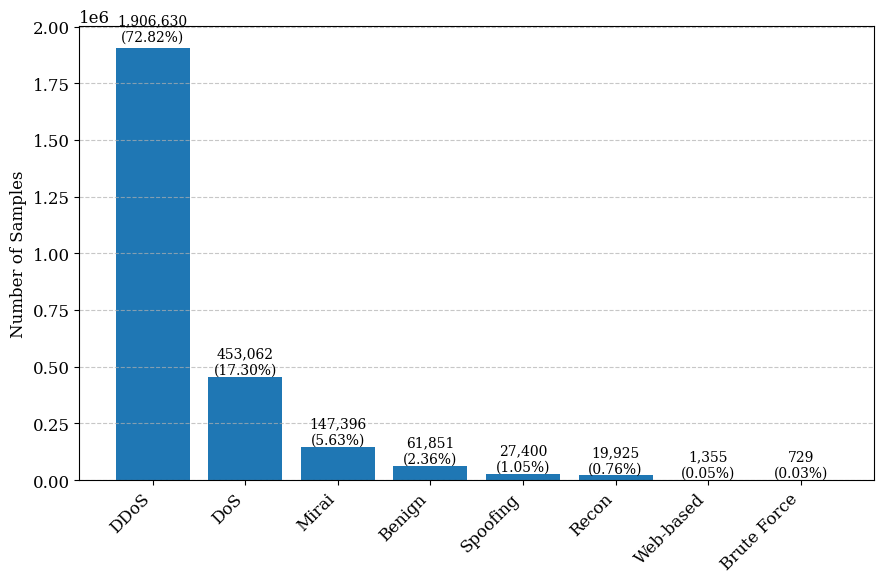

In [23]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is final_df

# Count samples and percentages
label_counts = df['label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(9, 6))
bars = plt.bar(label_counts.index, label_counts.values)

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.01*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
#plt.title('Drone IDS Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()


## **Decision Tree Before PCA**

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Separate features and target
X = df.drop(columns=['label'])
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Decision Tree
dt = DecisionTreeClassifier(
    random_state=42
)

# Fit the model
dt.fit(X_train, y_train)

# Prediction
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1_score = f1_score(y_test, y_pred, average='macro')


# Display metrics
print("===== Decision Tree Performance (Before PCA) =====")

print(f"Accuracy  : {accuracy:.5f}")
print(f"Precision : {precision:.5f}")
print(f"Recall    : {recall:.5f}")
print(f"F1-score  : {f1_score:.5f}")
print(classification_report(y_test, y_pred))

===== Decision Tree Performance (Before PCA) =====
Accuracy  : 0.99490
Precision : 0.83817
Recall    : 0.84918
F1-score  : 0.84341
              precision    recall  f1-score   support

      Benign       0.93      0.92      0.92     12370
 Brute Force       0.58      0.60      0.59       146
        DDoS       1.00      1.00      1.00    381326
         DoS       1.00      1.00      1.00     90613
       Mirai       1.00      1.00      1.00     29479
       Recon       0.82      0.83      0.83      3985
    Spoofing       0.86      0.86      0.86      5480
   Web-based       0.52      0.59      0.55       271

    accuracy                           0.99    523670
   macro avg       0.84      0.85      0.84    523670
weighted avg       0.99      0.99      0.99    523670



## **Decision Tree with PCA**

In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ---------------------------------------------------------
# 1. Features / target
# ---------------------------------------------------------
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# ---------------------------------------------------------
# 2. Pipeline: PCA -> Decision Tree
#    n_components=0.95 keeps enough components for 95% of
#    the variance. PCA is fit on TRAIN only (no leakage).
# ---------------------------------------------------------
pipe = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('dt',  DecisionTreeClassifier(random_state=42))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

# ---------------------------------------------------------
# 3. PCA info
# ---------------------------------------------------------
pca = pipe.named_steps['pca']
print(f"Original features   : {X_train.shape[1]}")
print(f"Components retained : {pca.n_components_}")
print(f"Variance explained  : {pca.explained_variance_ratio_.sum():.4f}")

# ---------------------------------------------------------
# 4. Metrics
# ---------------------------------------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

print("===== Decision Tree Performance (After PCA) =====")
print(f"Accuracy  : {acc:.5f}")
print(f"Precision : {prec:.5f}")
print(f"Recall    : {rec:.5f}")
print(f"F1-score  : {f1:.5f}")
print(classification_report(y_test, y_pred, zero_division=0))

Original features   : 46
Components retained : 22
Variance explained  : 0.9602
===== Decision Tree Performance (After PCA) =====
Accuracy  : 0.96111
Precision : 0.65927
Recall    : 0.66398
F1-score  : 0.66140
              precision    recall  f1-score   support

      Benign       0.80      0.80      0.80     12449
 Brute Force       0.17      0.20      0.18       124
        DDoS       0.98      0.98      0.98    381412
         DoS       0.92      0.92      0.92     90559
       Mirai       0.99      0.99      0.99     29473
       Recon       0.58      0.59      0.58      3874
    Spoofing       0.64      0.63      0.63      5513
   Web-based       0.19      0.19      0.19       266

    accuracy                           0.96    523670
   macro avg       0.66      0.66      0.66    523670
weighted avg       0.96      0.96      0.96    523670



## **Model with and without dfferent PCA**

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

results = []

for name, n in [("No PCA", None), ("PCA 5", 5), ("PCA 10", 10), ("PCA 20", 20), ("PCA 0.95", 0.95)]:
    if n is None:
        Xtr, Xte, k = X_train, X_test, X_train.shape[1]
    else:
        pca = PCA(n_components=n, random_state=42)
        Xtr = pca.fit_transform(X_train)
        Xte = pca.transform(X_test)
        k = pca.n_components_

    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(Xtr, y_train)
    y_pred = dt.predict(Xte)

    results.append({
        'Setting'  : name,
        'Features' : k,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1'       : f1_score(y_test, y_pred, average='macro', zero_division=0),
    })

print(pd.DataFrame(results).round(5).to_string(index=False))

 Setting  Features  Accuracy  Precision  Recall      F1
  No PCA        46   0.99497    0.83518 0.84662 0.84024
   PCA 5         5   0.95496    0.60372 0.61119 0.60694
  PCA 10        10   0.95894    0.61795 0.62605 0.62144
  PCA 20        20   0.96089    0.64925 0.65613 0.65227
PCA 0.95        22   0.96111    0.65927 0.66398 0.66140


## **Values of PC**

In [28]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)
Xtr_pca = pca.fit_transform(X_train)

pca_df = pd.DataFrame(Xtr_pca, columns=[f'PCA{i}' for i in range(1, 11)])

for col in pca_df.columns:
    print(f"\n{col}:")
    print(pca_df[col].head(10).round(4).to_string(index=False))


PCA1:
-0.4555
-1.5821
-1.0317
-0.5915
-0.9940
-0.9940
-1.5821
 3.6885
-0.9161
-1.0317

PCA2:
-0.1754
 6.0207
-0.9539
-0.1918
-0.4007
-0.4008
 6.0207
-1.4741
-0.9410
-0.9538

PCA3:
 1.3552
-1.4005
-0.0994
 1.3290
 1.2671
 1.2668
-1.4004
-3.5006
-0.0760
-0.0989

PCA4:
-1.2953
 0.7628
 0.5457
-1.2946
-0.9409
-0.9412
 0.7628
 1.9193
 0.5451
 0.5464

PCA5:
-0.0002
-0.0005
-0.0103
 0.0111
 0.0109
 0.0109
-0.0005
 0.1571
-0.0215
-0.0103

PCA6:
-2.3266
 0.0941
-0.8687
-2.3311
 1.7406
 1.7406
 0.0941
 1.6640
-0.8676
-0.8690

PCA7:
-0.8178
-0.1571
-0.1546
-0.8288
 0.3632
 0.3632
-0.1570
-0.5376
-0.1448
-0.1538

PCA8:
 0.1650
 0.0375
 0.0858
 0.1651
-0.1215
-0.1215
 0.0375
 0.0417
 0.0859
 0.0857

PCA9:
-1.1394
 0.0043
 2.2220
-1.2010
-0.3059
-0.3058
 0.0043
-2.7376
 2.2730
 2.2217

PCA10:
 2.8827
-0.1400
-0.4504
 2.8725
-0.3271
-0.3271
-0.1400
 1.0069
-0.4451
-0.4504


### **How many components do I need?**

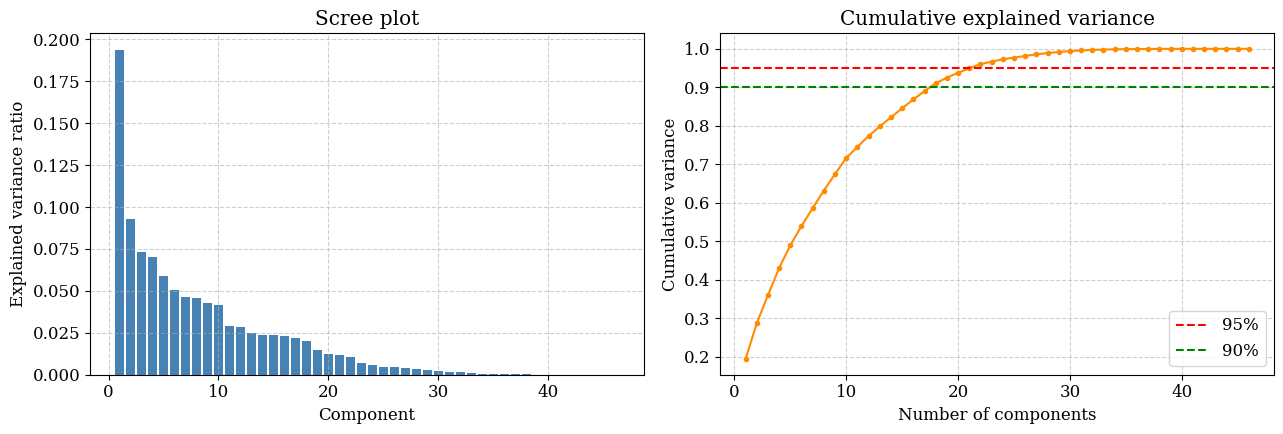

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_train)
var = pca_full.explained_variance_ratio_
cum = np.cumsum(var)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(range(1, len(var) + 1), var, color='steelblue')
ax[0].set_xlabel('Component')
ax[0].set_ylabel('Explained variance ratio')
ax[0].set_title('Scree plot')

ax[1].plot(range(1, len(cum) + 1), cum, marker='o', ms=3, color='darkorange')
ax[1].axhline(0.95, ls='--', c='red', label='95%')
ax[1].axhline(0.90, ls='--', c='green', label='90%')
ax[1].set_xlabel('Number of components')
ax[1].set_ylabel('Cumulative variance')
ax[1].set_title('Cumulative explained variance')
ax[1].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Thank You**